In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve().parent
exp_dir = repo_root / 'exp'
exp_dir


WindowsPath('C:/Users/prana/Documents/Projects/berkeley/cs285/hw/hw2/exp')

In [86]:
def collect_experiments(names: dict):
    exps = list(exp_dir.glob('*/log.csv'))

    frames = []

    for key, experiment in names.items():
        for p in exps:
            if p.parent.name.startswith(key):
                run_name = p.parent.name
                df = pd.read_csv(p)
                df['experiment'] = experiment
                df['run_name'] = run_name
                frames.append(df)
                break

    plot_df = pd.concat(frames, ignore_index=True)

    plot_df["experiment"] = pd.Categorical(
        plot_df["experiment"],
        categories=list(names.values()),
        ordered=True,
    )

    print(
        plot_df[['experiment', 'run_name']]
        .drop_duplicates()
        .to_string(index=False)
    )

    return plot_df

# Collect CartPole runs without '_lb' in experiment name
log_paths = sorted(exp_dir.glob('CartPole-v0_cartpole*_sd*_*/log.csv'))
log_paths = [p for p in log_paths if '_lb_' not in p.parent.name]

name_map = {
    'CartPole-v0_cartpole_rtg_na_sd': 'cartpole_rtg_na',
    'CartPole-v0_cartpole_rtg_sd': 'cartpole_rtg',
    'CartPole-v0_cartpole_na_sd': 'cartpole_na',
    'CartPole-v0_cartpole_sd': 'cartpole',
}

def to_label(run_name: str) -> str:
    for key, label in name_map.items():
        if run_name.startswith(key):
            return label
    return run_name

frames = []
for log_path in log_paths:
    run_name = log_path.parent.name
    df = pd.read_csv(log_path)
    df['experiment'] = to_label(run_name)
    df['run_name'] = run_name
    frames.append(df)

if not frames:
    raise FileNotFoundError('No matching CartPole non-lb logs found under hw2/exp')

plot_df = pd.concat(frames, ignore_index=True)

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=140)
sns.lineplot(
    data=plot_df,
    x='Train_EnvstepsSoFar',
    y='Train_AverageReturn',
    hue='experiment',
    ax=ax,
)
ax.set_title('CartPole (non-lb): Average Return vs Environment Steps')
ax.set_xlabel('Number of Environment Steps (Train_EnvstepsSoFar)')
ax.set_ylabel('Average Return (Train_AverageReturn)')
ax.legend(title='Experiment')
plt.tight_layout()

out_path = repo_root / 'scripts' / 'cartpole_non_lb_learning_curves.png'
fig.savefig(out_path, bbox_inches='tight')
print(f'Saved figure to: {out_path}')
plt.show()

plot_df[['experiment', 'run_name']].drop_duplicates().sort_values('experiment')


In [89]:
def make_plot(
    file_name: str, 
    df, 
    title: str, 
    y: str = 'Train_AverageReturn', 
    y_label: str = 'Average Return', 
    x = 'Train_EnvstepsSoFar', 
    x_label='# Environment Steps', 
    std=None,
    smooth = None
):
    sns.set_theme(style='whitegrid')
    if smooth is not None:
        df = df.copy()
        df = df.sort_values(x)
    
        df[y] = (
            df
            .groupby("experiment", observed=True)[y]
            .transform(lambda s: s.ewm(alpha=smooth, adjust=False).mean())
        )
        
        if std is not None:
            df[std] = (
                df
                .groupby("experiment", observed=True)[std]
                .transform(lambda s: s.ewm(alpha=smooth, adjust=False).mean())
            )
            
    fig, ax = plt.subplots(figsize=(8, 5), dpi=140)
    sns.lineplot(
        data=df,
        x=x,
        y=y,
        hue='experiment',
        ax=ax,
    )
    if std is not None:
        line_colors = {}
        for line in ax.lines:
            label = line.get_label()
            if label != "_nolegend_":
                line_colors[label] = line.get_color()

    
        for exp, sub in df.groupby("experiment", sort=False):
            sub = sub.sort_values(x)
            c = line_colors.get(exp)
        
            lo = sub[y] - sub[std]
            hi = sub[y] + sub[std]
        
            ax.fill_between(sub[x], lo, hi, color=c, alpha=0.2, edgecolor="none")

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.legend(title='Experiment')
    plt.tight_layout()
    
    out_path = repo_root / 'scripts' / file_name
    fig.savefig(out_path, bbox_inches='tight')
    print(f'Saved figure to: {out_path}')
    plt.show()


IndentationError: unexpected indent (3095585473.py, line 17)

     experiment                                        run_name
       cartpole        CartPole-v0_cartpole_sd1_20260226_215825
    cartpole_na     CartPole-v0_cartpole_na_sd1_20260226_220010
   cartpole_rtg    CartPole-v0_cartpole_rtg_sd1_20260226_215945
cartpole_rtg_na CartPole-v0_cartpole_rtg_na_sd1_20260226_220024
Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw2\scripts\cartpole_sb.png


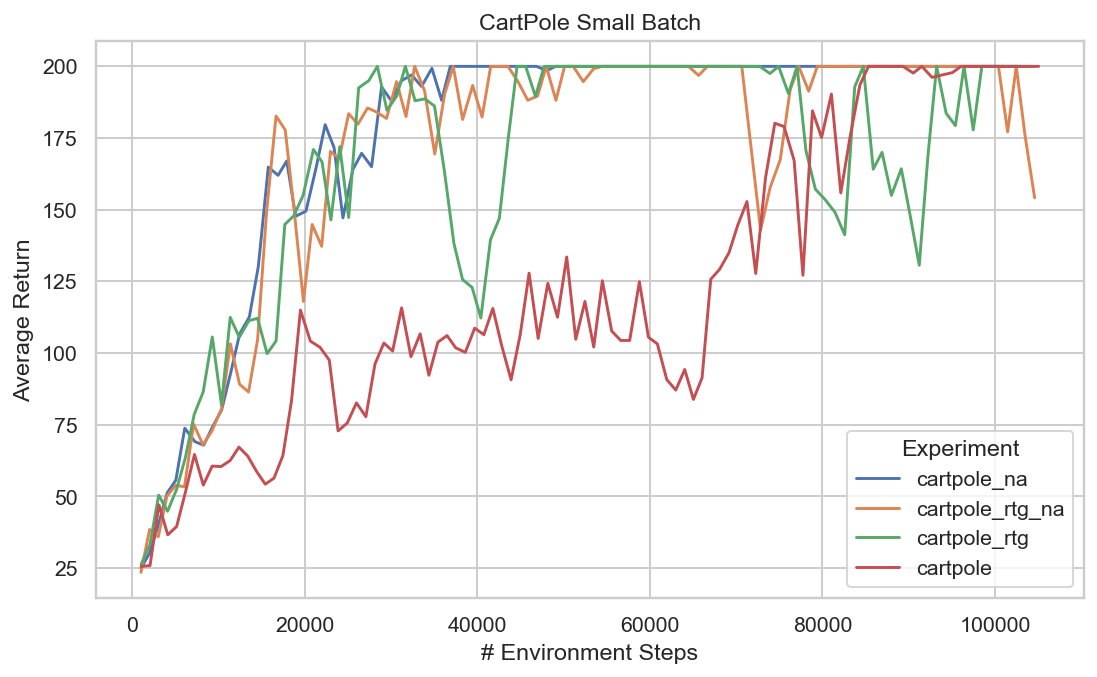

In [55]:
cartpole_sb = collect_experiments({
    'CartPole-v0_cartpole_rtg_na_sd': 'cartpole_rtg_na',
    'CartPole-v0_cartpole_rtg_sd': 'cartpole_rtg',
    'CartPole-v0_cartpole_na_sd': 'cartpole_na',
    'CartPole-v0_cartpole_sd': 'cartpole',
})
make_plot('cartpole_sb.png', cartpole_sb, 'CartPole Small Batch')

        experiment                                           run_name
cartpole_lb_rtg_na CartPole-v0_cartpole_lb_rtg_na_sd1_20260226_220209
   cartpole_lb_rtg    CartPole-v0_cartpole_lb_rtg_sd1_20260226_220052
    cartpole_lb_na     CartPole-v0_cartpole_lb_na_sd1_20260226_220055
       cartpole_lb        CartPole-v0_cartpole_lb_sd1_20260226_220048
Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw2\scripts\cartpole_lb.png


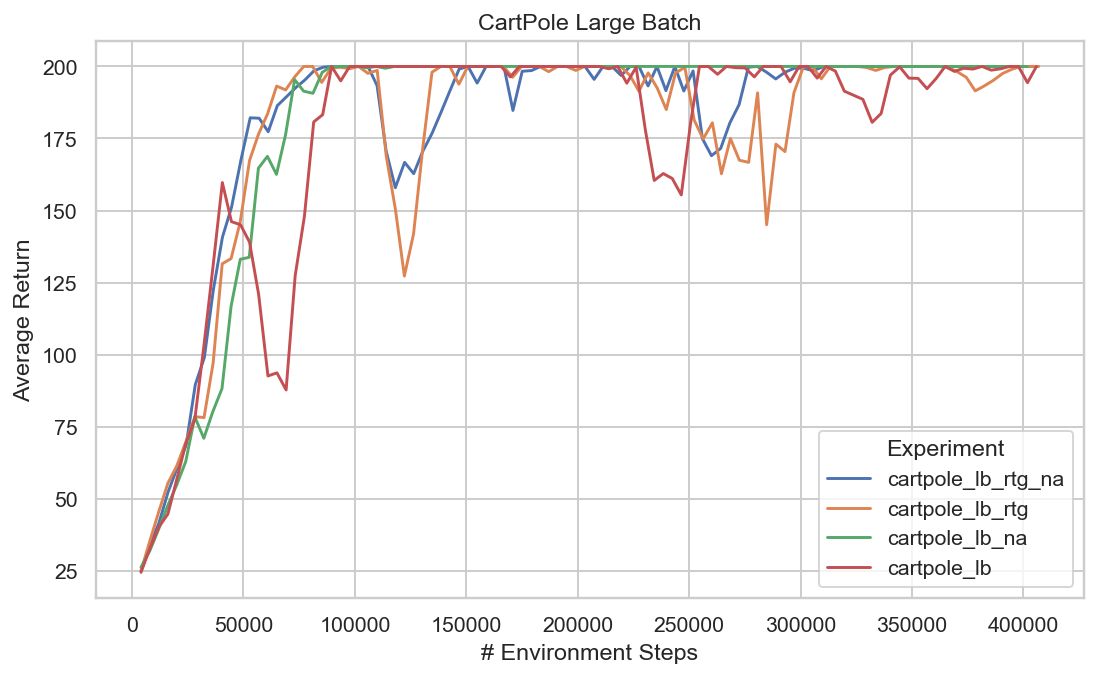

In [88]:
cartpole_lb = collect_experiments({
    'CartPole-v0_cartpole_lb_rtg_na_sd': 'cartpole_lb_rtg_na',
    'CartPole-v0_cartpole_lb_rtg_sd': 'cartpole_lb_rtg',
    'CartPole-v0_cartpole_lb_na_sd': 'cartpole_lb_na',
    'CartPole-v0_cartpole_lb_sd': 'cartpole_lb',
})
make_plot('cartpole_lb.png', cartpole_lb, 'CartPole Large Batch')

            experiment                                                          run_name
              baseline               HalfCheetah-v4_cheetah_baseline_sd1_20260226_220548
baseline_lower_blr_bgs HalfCheetah-v4_cheetah_baseline_lower_blr_bgs_sd1_20260226_221112
Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw2\scripts\cheetah_baseline_loss.png


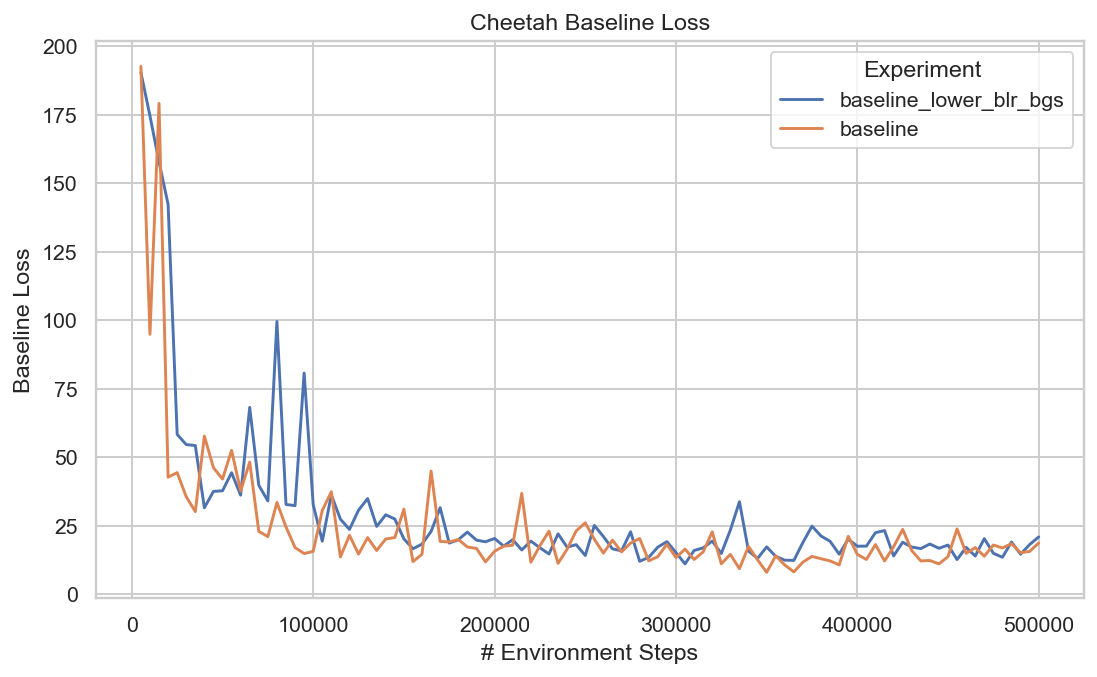

In [62]:
cheetah_baseline_loss = collect_experiments({
    'HalfCheetah-v4_cheetah_baseline_sd1_20260226_220548': 'baseline',
    'HalfCheetah-v4_cheetah_baseline_lower_blr_bgs_sd1_20260226_221112': 'baseline_lower_blr_bgs',
})
make_plot('cheetah_baseline_loss.png', cheetah_baseline_loss, 'Cheetah Baseline Loss', y='Baseline Loss', y_label='Baseline Loss')

           experiment                                                          run_name
              cheetah                        HalfCheetah-v4_cheetah_sd1_20260226_220546
     cheetah_baseline               HalfCheetah-v4_cheetah_baseline_sd1_20260226_220548
cheetah_lower_blr_bgs HalfCheetah-v4_cheetah_baseline_lower_blr_bgs_sd1_20260226_221112
Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw2\scripts\cheetah_eval_return.png


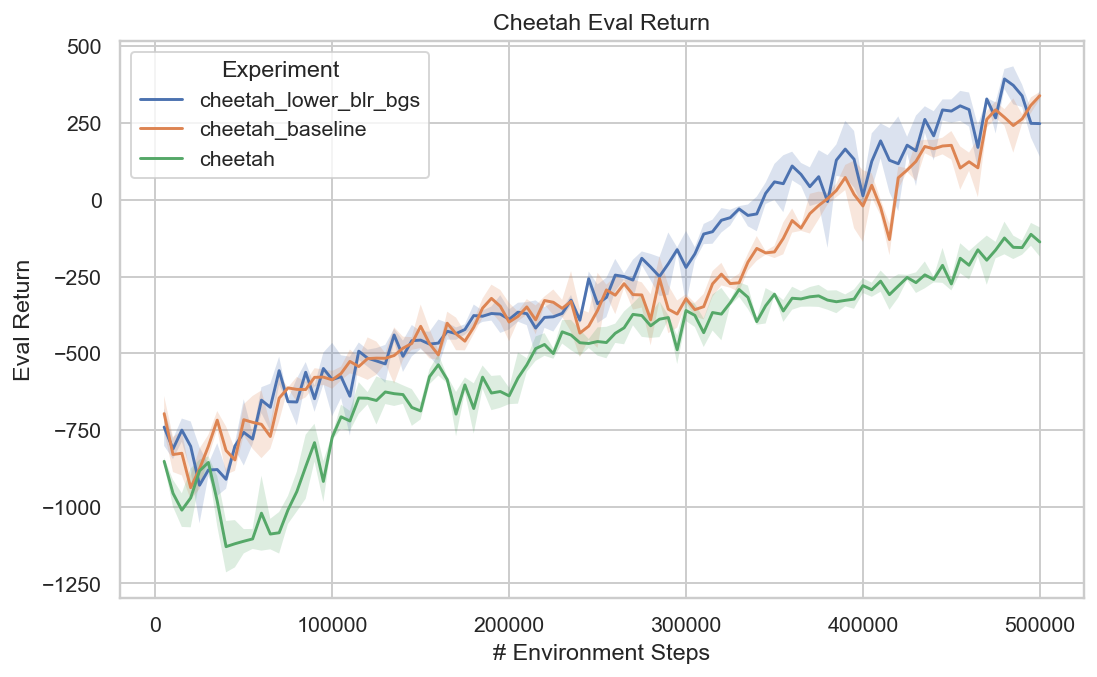

In [61]:
cheetah_eval_return = collect_experiments({
    'HalfCheetah-v4_cheetah_baseline_sd1_20260226_220548': 'baseline',
    'HalfCheetah-v4_cheetah_baseline_lower_blr_bgs_sd1_20260226_221112': 'baseline_lower_blr_bgs',
    'HalfCheetah-v4_cheetah_sd1_20260226_220546': 'cheetah'
})
make_plot('cheetah_eval_return.png', cheetah_eval_return, 'Cheetah Eval Return', y='Eval_AverageReturn', y_label='Eval Return', std='Eval_StdReturn')

experiment                                                   run_name
     λ = 0    LunarLander-v2_lunar_lander_lambda0_sd1_20260226_224054
  λ = 0.95 LunarLander-v2_lunar_lander_lambda0.95_sd1_20260226_224131
  λ = 0.98 LunarLander-v2_lunar_lander_lambda0.98_sd1_20260226_224138
  λ = 0.99 LunarLander-v2_lunar_lander_lambda0.99_sd1_20260226_224812
     λ = 1    LunarLander-v2_lunar_lander_lambda1_sd1_20260226_231315
Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw2\scripts\lunar_lander_lambda.png


C:\Users\prana\AppData\Local\Temp\ipykernel_41076\153190649.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("experiment")[y]


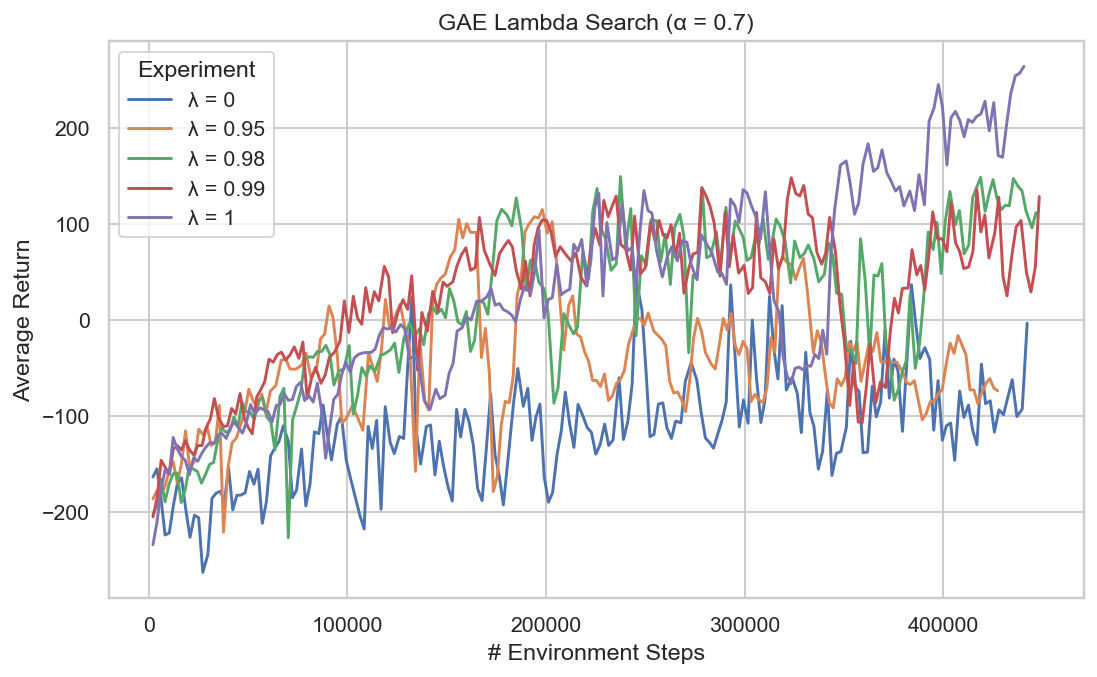

In [87]:
lunar_lander_lambda = collect_experiments({
    'LunarLander-v2_lunar_lander_lambda0_': 'λ = 0',
    'LunarLander-v2_lunar_lander_lambda0.95_': 'λ = 0.95',
    'LunarLander-v2_lunar_lander_lambda0.98_': 'λ = 0.98',
    'LunarLander-v2_lunar_lander_lambda0.99_': 'λ = 0.99',
    'LunarLander-v2_lunar_lander_lambda1_': 'λ = 1',
})
make_plot('lunar_lander_lambda.png', lunar_lander_lambda, 'GAE Lambda Search (α = 0.7)', smooth=0.7)